# EV Purchase Prediction — Final Pipeline
Predicts `Will_Buy_EV` probability using a tuned LightGBM model.
Best cross-validated AUC: **0.9422**

## 1. Load data

In [2]:
import pandas as pd
import numpy as np

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train:", train.shape)
print("Test :", test.shape)

train.head()

Train: (668665, 15)
Test : (286571, 14)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [3]:
# Basic sanity checks
print(train.dtypes.value_counts())
print("Duplicates:", train.duplicated().sum())

missing = train.isnull().sum()
print("Missing values:\n", missing[missing > 0].sort_values(ascending=False))

object     7
int64      5
float64    3
Name: count, dtype: int64
Duplicates: 0
Missing values:
 Series([], dtype: int64)


## 2. Prepare target and features

In [4]:
# Target: map Yes/No -> 1/0
y = train["Will_Buy_EV"].map({'Yes': 1, 'No': 0})

# Features (drop id and target)
X = train.drop(columns=["Will_Buy_EV", "id"])
X_test = test.drop(columns=["id"])
test_ids = test["id"].copy()

print("X shape:", X.shape)
print("X_test shape:", X_test.shape)
print("y balance:\n", y.value_counts(normalize=True))

X shape: (668665, 13)
X_test shape: (286571, 13)
y balance:
 Will_Buy_EV
0    0.825355
1    0.174645
Name: proportion, dtype: float64


## 3. Encode categorical features (one-hot)
Train and test are combined first so both end up with identical dummy columns.

In [5]:
all_data = pd.concat([X, X_test], axis=0)
all_data = pd.get_dummies(all_data)

X_encoded = all_data.iloc[:len(X)]
X_test_encoded = all_data.iloc[len(X):]

print(X_encoded.shape, X_test_encoded.shape)

(668665, 24) (286571, 24)


## 4. Baseline model (Logistic Regression)
Quick sanity-check baseline before moving to a stronger model.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

cv = KFold(n_splits=5, shuffle=True, random_state=42)

baseline_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
baseline_scores = cross_val_score(baseline_model, X_encoded, y, cv=cv, scoring="roc_auc", n_jobs=-1)

print("Baseline (Logistic Regression) mean AUC:", baseline_scores.mean())

Baseline (Logistic Regression) mean AUC: 0.9381011598787715


## 5. Final model — tuned LightGBM
Hyperparameters found via Optuna search (50 trials, 5-fold CV).

In [7]:
from lightgbm import LGBMClassifier

best_lgbm_params = {
    'n_estimators': 964,
    'learning_rate': 0.12454531691539797,
    'max_depth': 3,
    'num_leaves': 94,
    'min_child_samples': 82,
    'subsample': 0.7319915381690714,
    'colsample_bytree': 0.6382739357154379,
    'reg_alpha': 3.467182142686367e-08,
    'reg_lambda': 0.0007171819316649324
}

model = LGBMClassifier(**best_lgbm_params, random_state=42, n_jobs=-1, verbose=-1)

cv_scores = cross_val_score(model, X_encoded, y, cv=cv, scoring="roc_auc", n_jobs=-1)
print("Fold scores:", cv_scores)
print("Mean AUC:", cv_scores.mean())
print("Std:", cv_scores.std())

Fold scores: [0.94241559 0.941217   0.94313386 0.94183552 0.94251889]
Mean AUC: 0.9422241716260045
Std: 0.0006506113183187266


## 6. Feature importance (diagnostic)
`Environmental_Concern_Level` and `Subsidy_Available` are by far the strongest predictors.

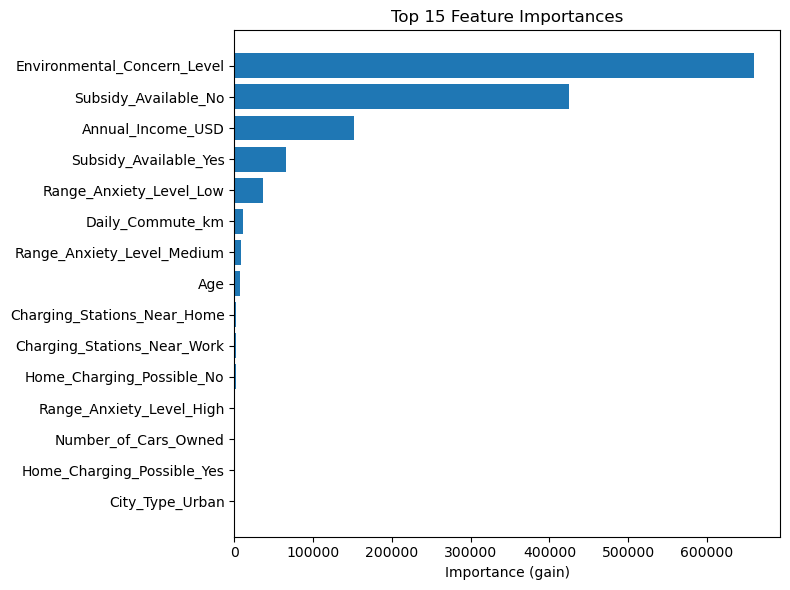

,feature,importance
6,Environmental_Concern_Level,659799.382176
19,Subsidy_Available_No,424874.301646
1,Annual_Income_USD,151793.016238
20,Subsidy_Available_Yes,65683.666658
22,Range_Anxiety_Level_Low,35889.572105
2,Daily_Commute_km,11391.914788
23,Range_Anxiety_Level_Medium,8018.576767
0,Age,6621.450308
4,Charging_Stations_Near_Home,2194.980154
5,Charging_Stations_Near_Work,1766.093260


In [8]:
import matplotlib.pyplot as plt

model.fit(X_encoded, y)

importance_df = pd.DataFrame({
    "feature": X_encoded.columns,
    "importance": model.booster_.feature_importance(importance_type="gain")
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(importance_df["feature"][:15][::-1], importance_df["importance"][:15][::-1])
plt.xlabel("Importance (gain)")
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()

importance_df.head(10)

## 7. Train final model on full data and predict

In [9]:
final_model = LGBMClassifier(**best_lgbm_params, random_state=42, n_jobs=-1, verbose=-1)
final_model.fit(X_encoded, y)

prediction = final_model.predict_proba(X_test_encoded)[:, 1]

print(pd.Series(prediction).describe())

count    2.865710e+05
mean     1.747032e-01
std      2.705461e-01
min      1.730479e-07
25%      2.346854e-03
50%      1.835177e-02
75%      2.647188e-01
max      9.761313e-01
dtype: float64


## 8. Build submission file

In [10]:
submission = pd.DataFrame({
    "id": test_ids,
    "Will_Buy_EV": prediction
})

submission.to_csv("submission.csv", index=False)

print("Saved submission.csv:", submission.shape)
submission.head()

Saved submission.csv: (286571, 2)


,id,Will_Buy_EV
0,668665,0.009940
1,668666,0.019687
2,668667,0.005147
3,668668,0.001780
4,668669,0.023948
